<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FML_PRAC_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report


In [4]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [5]:
data = pd.read_csv("credit_risk_dataset.csv")

print("\nDATASET")
print(data)


DATASET
       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_

In [6]:
print("\nDATASET SHAPE")
print(data.shape)

print("\nDATASET INFORMATION")
print(data.info())

print("\nSTATISTICAL SUMMARY")
print(data.describe())



DATASET SHAPE
(32581, 12)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memor

In [7]:
print("\nMISSING VALUES")
print(data.isnull().sum())



MISSING VALUES
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64



CLASS DISTRIBUTION
loan_status
0    25473
1     7108
Name: count, dtype: int64


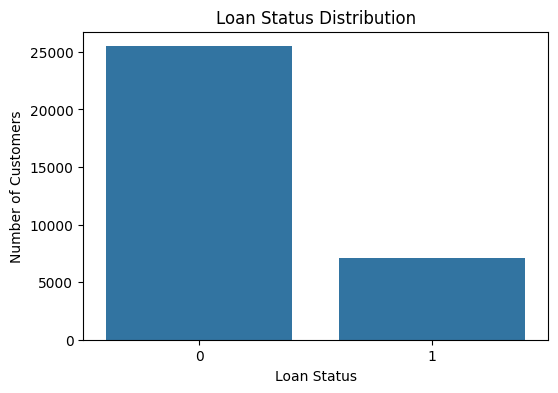

In [8]:

print("\nCLASS DISTRIBUTION")
print(data["loan_status"].value_counts())


plt.figure(figsize=(6, 4))
sns.countplot(x=data["loan_status"])
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

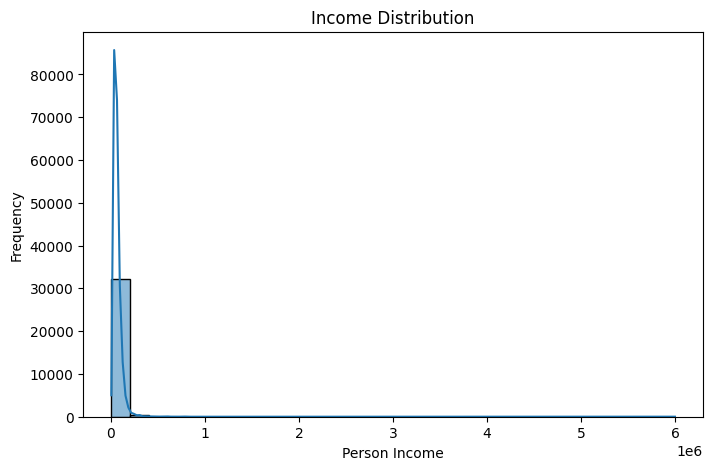

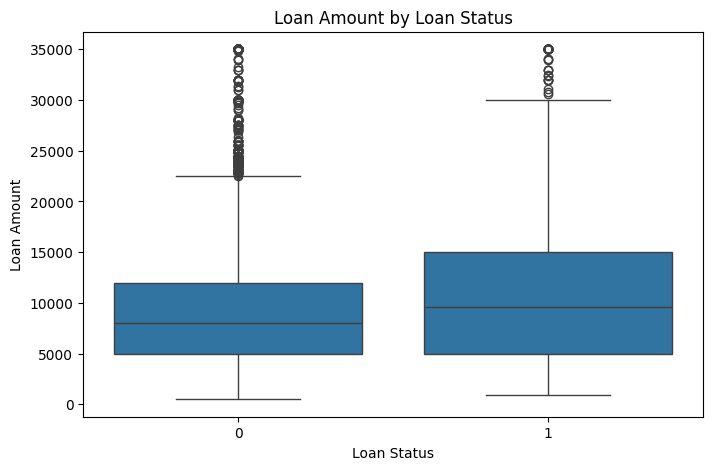

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data["person_income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.xlabel("Person Income")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(x=data["loan_status"], y=data["loan_amnt"])
plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

In [10]:

data = data.dropna()

label_encoder = LabelEncoder()

categorical_columns = data.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])

In [11]:
X = data.drop("loan_status", axis=1)
y = data["loan_status"]

print("\nINPUT FEATURES")
print(X.head())

print("\nTARGET VARIABLE")
print(y.head())


INPUT FEATURES
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0            4           3      35000          16.02                 0.59   
1            1           1       1000          11.14                 0.10   
2            3           2       5500          12.87                 0.57   
3            3           2      35000          15.23                 0.53   
4            3           2      35000          14.27                 0.55   

   cb_person_default_on_file  cb_person_cred_hist_length  
0                

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred_rf = random_forest.predict(X_test_scaled)

In [17]:

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRANDOM FOREST PERFORMANCE")
print("Accuracy  :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall    :", rf_recall)
print("F1-Score  :", rf_f1)

print("\nRANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST PERFORMANCE
Accuracy  : 0.927199720670391
Precision : 0.963963963963964
Recall    : 0.6897663174858985
F1-Score  : 0.8041333959605449

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      4487
           1       0.96      0.69      0.80      1241

    accuracy                           0.93      5728
   macro avg       0.94      0.84      0.88      5728
weighted avg       0.93      0.93      0.92      5728



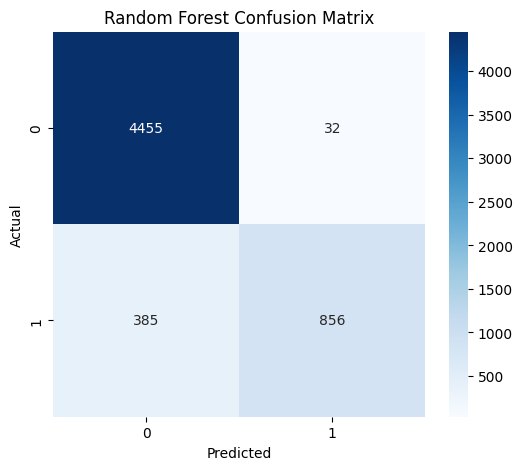

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

adaboost.fit(X_train_scaled, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [20]:
y_pred_ab = adaboost.predict(X_test_scaled)

In [21]:
ab_accuracy = accuracy_score(y_test, y_pred_ab)
ab_precision = precision_score(y_test, y_pred_ab)
ab_recall = recall_score(y_test, y_pred_ab)
ab_f1 = f1_score(y_test, y_pred_ab)

print("\nADABOOST PERFORMANCE")
print("Accuracy  :", ab_accuracy)
print("Precision :", ab_precision)
print("Recall    :", ab_recall)
print("F1-Score  :", ab_f1)

print("\nADABOOST CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_ab))


ADABOOST PERFORMANCE
Accuracy  : 0.883554469273743
Precision : 0.8072805139186295
Recall    : 0.6075745366639806
F1-Score  : 0.6933333333333334

ADABOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4487
           1       0.81      0.61      0.69      1241

    accuracy                           0.88      5728
   macro avg       0.85      0.78      0.81      5728
weighted avg       0.88      0.88      0.88      5728



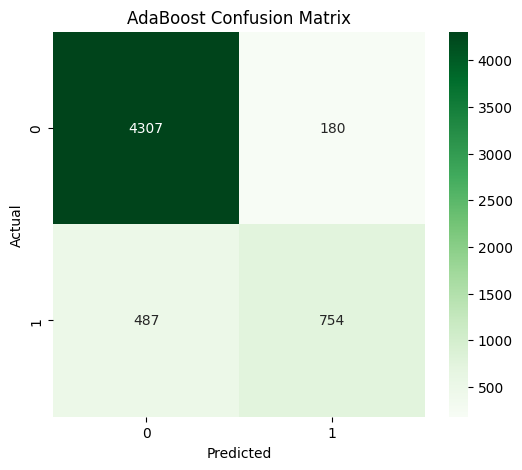

In [22]:
cm_ab = confusion_matrix(y_test, y_pred_ab)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ab,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


RANDOM FOREST FEATURE IMPORTANCE
                       Feature  Importance
8          loan_percent_income    0.233066
1                person_income    0.136292
7                loan_int_rate    0.125665
5                   loan_grade    0.108792
2        person_home_ownership    0.099480
4                  loan_intent    0.074656
6                    loan_amnt    0.069925
3            person_emp_length    0.063104
0                   person_age    0.043427
10  cb_person_cred_hist_length    0.034865
9    cb_person_default_on_file    0.010728


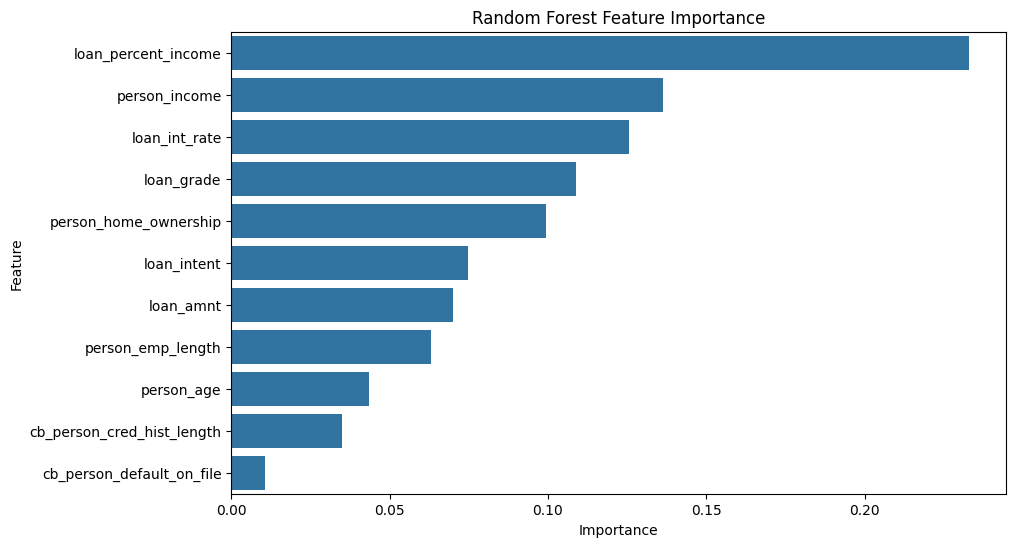

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")
print(feature_importance)


plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [24]:

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    "AdaBoost": [
        ab_accuracy,
        ab_precision,
        ab_recall,
        ab_f1
    ]
})

print("\nFINAL PERFORMANCE COMPARISON")
print(comparison)



FINAL PERFORMANCE COMPARISON
      Metric  Random Forest  AdaBoost
0   Accuracy       0.927200  0.883554
1  Precision       0.963964  0.807281
2     Recall       0.689766  0.607575
3   F1-Score       0.804133  0.693333


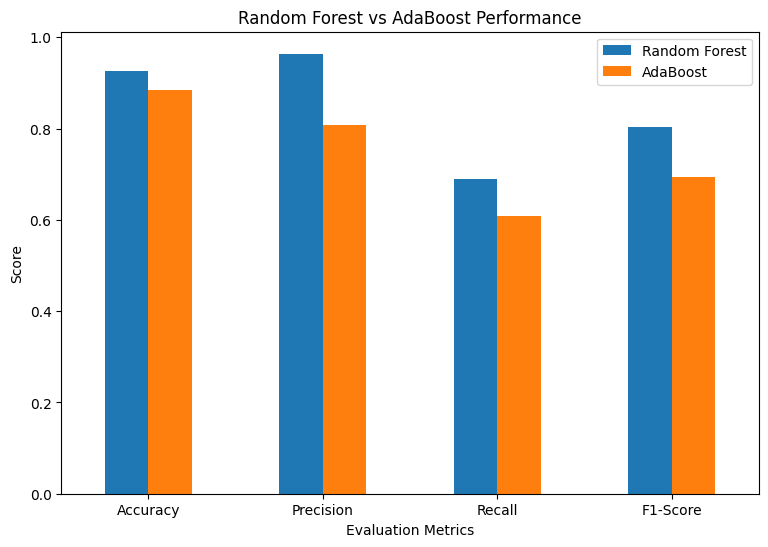

In [25]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Random Forest vs AdaBoost Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [26]:
print("\nFINAL CONCLUSION")

if rf_f1 > ab_f1:
    print("Random Forest performed better than AdaBoost based on F1-Score.")
elif ab_f1 > rf_f1:
    print("AdaBoost performed better than Random Forest based on F1-Score.")
else:
    print("Both models performed equally based on F1-Score.")

print("Both models were developed and evaluated for credit risk assessment.")
print("Their performance was compared using Accuracy, Precision, Recall and F1-Score.")


FINAL CONCLUSION
Random Forest performed better than AdaBoost based on F1-Score.
Both models were developed and evaluated for credit risk assessment.
Their performance was compared using Accuracy, Precision, Recall and F1-Score.
